In [ ]:
import pandas as pd
df= pd.read_csv('dataset_cleaned.csv')
df.shape

(1459129, 7)

In [ ]:
df.head()

,lang,country,reconstructed_text,main_sentiment,sentiment_score,main_stance,stance_score
0,cs,Slovakia,weekend selection zelensky was not prepared fo...,neutral,0.5044,Unsure,0.8667
1,ro,Italy,the ukrainian war charles michel of kiev the s...,neutral,0.9146,Unsure,0.4485
2,te,India,the invention of the shark drone is a new chap...,neutral,0.5799,Unsure,0.8056
3,te,India,will nuclear war be over those countries that ...,negative,0.7900,Unsure,0.2205
4,te,India,boys fight students fight in coaching center c...,negative,0.6543,Pro Ukraine,0.9286


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459129 entries, 0 to 1459128
Data columns (total 7 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   lang                1459129 non-null  object 
 1   country             1459129 non-null  object 
 2   reconstructed_text  1458115 non-null  object 
 3   main_sentiment      1459129 non-null  object 
 4   sentiment_score     1459129 non-null  float64
 5   main_stance         1459129 non-null  object 
 6   stance_score        1459129 non-null  float64
dtypes: float64(2), object(5)
memory usage: 77.9+ MB


In [ ]:
df.isnull().sum()

lang                     0
country                  0
reconstructed_text    1014
main_sentiment           0
sentiment_score          0
main_stance              0
stance_score             0
dtype: int64

In [ ]:
null_indices = df[df["reconstructed_text"].isna()].index

print(null_indices.tolist())

[312945, 388666, 469464, 469527, 542405, 615033, 615463, 620447, 637773, 643356, 643357, 643358, 654157, 662433, 667335, 674256, 674262, 674263, 675620, 676125, 684249, 704334, 704474, 704655, 704783, 704825, 704892, 704904, 704911, 704947, 705099, 705120, 705209, 705396, 705529, 705849, 706337, 706348, 706495, 706807, 706888, 706996, 725579, 932929, 932980, 974879, 1015963, 1015964, 1015965, 1015966, 1015967, 1015968, 1015970, 1015971, 1015972, 1015973, 1015974, 1015975, 1016493, 1016494, 1016495, 1016496, 1016497, 1016498, 1016499, 1016500, 1016501, 1016502, 1025766, 1030418, 1030456, 1036470, 1036471, 1036472, 1036473, 1036474, 1036475, 1036707, 1040493, 1041653, 1041654, 1041655, 1041656, 1042081, 1042082, 1042083, 1047932, 1047933, 1047934, 1047935, 1047936, 1047937, 1047938, 1047939, 1047940, 1047941, 1047943, 1047944, 1047945, 1047946, 1047947, 1049678, 1053908, 1053909, 1053910, 1056862, 1056863, 1056864, 1056865, 1056866, 1056867, 1061008, 1067839, 1067840, 1067841, 1072254, 1

In [ ]:
df['reconstructed_text'].iloc[1402683]

nan

In [ ]:
df = df.dropna(subset=["reconstructed_text"])

print(df.shape)

(1458115, 7)


In [ ]:
df.duplicated().sum()

np.int64(9)

In [ ]:
duplicate_indices = df[df.duplicated()].index.tolist()

print(len(duplicate_indices))
print(duplicate_indices)

9
[241283, 693763, 694182, 694192, 694229, 694455, 697487, 1115233, 1455320]


In [ ]:
df = df.drop_duplicates()

In [ ]:
df["reconstructed_text"].duplicated().sum()

np.int64(106273)

In [ ]:
df["main_stance"].value_counts()

main_stance
Unsure         1320036
Pro Ukraine     113556
Pro Russia       24514
Name: count, dtype: int64

In [ ]:
df["main_sentiment"].value_counts()

main_sentiment
neutral     855479
negative    578928
positive     23699
Name: count, dtype: int64

In [ ]:
pd.crosstab(
    df["main_sentiment"],
    df["main_stance"],
    margins=True
)

main_stance,Pro Russia,Pro Ukraine,Unsure,All
main_sentiment,,,,
negative,7658,53346,517924,578928
neutral,16045,57351,782083,855479
positive,811,2859,20029,23699
All,24514,113556,1320036,1458106


In [ ]:
print(df["lang"].value_counts().head(20))

lang
en    557149
ar    165470
es    145041
fr    108330
de     71905
it     52561
tr     48052
fa     41665
uk     41325
ru     37940
pt     37327
he     20933
hi     16535
pl     15753
ca     13726
id     12626
nl     12578
el     11415
ko      7425
ur      5068
Name: count, dtype: int64


In [ ]:
from collections import Counter

all_words = " ".join(
    df["reconstructed_text"].dropna()
).split()

word_freq = Counter(all_words)

print(word_freq.most_common(50))

[('the', 1748698), ('ukraine', 990209), ('of', 916481), ('in', 873226), ('to', 830909), ('russia', 567571), ('and', 520803), ('a', 500070), ('russian', 446858), ('war', 411646), ('on', 366513), ('is', 291454), ('ukrainian', 256471), ('for', 256021), ('with', 193495), ('that', 193458), ('has', 178050), ('from', 171631), ('putin', 164378), ('are', 137630), ('by', 134637), ('as', 132507), ('will', 123496), ('us', 117167), ('president', 115460), ('have', 111106), ('invasion', 109181), ('its', 107407), ('at', 106251), ('it', 102590), ('military', 93963), ('said', 88613), ('says', 87556), ('s', 84467), ('after', 82837), ('not', 81373), ('be', 81339), ('was', 78921), ('an', 77226), ('more', 72993), ('forces', 69231), ('we', 68892), ('kiev', 67506), ('against', 66567), ('zelensky', 65566), ('his', 65403), ('this', 64631), ('attack', 61908), ('russias', 60656), ('been', 55946)]


In [ ]:
vocab = set()

for text in df["reconstructed_text"].dropna():
    vocab.update(text.split())

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 194028


In [ ]:
stance_percent = (
    df["main_stance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(stance_percent)

main_stance
Unsure         90.53
Pro Ukraine     7.79
Pro Russia      1.68
Name: proportion, dtype: float64


In [ ]:
sentiment_percent = (
    df["main_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percent)

main_sentiment
neutral     58.67
negative    39.70
positive     1.63
Name: proportion, dtype: float64


In [ ]:
pd.crosstab(
    df["main_sentiment"],
    df["main_stance"]
)

main_stance,Pro Russia,Pro Ukraine,Unsure
main_sentiment,,,
negative,7658,53346,517924
neutral,16045,57351,782083
positive,811,2859,20029


In [ ]:
stance_sentiment_pct = (
    pd.crosstab(
        df["main_sentiment"],
        df["main_stance"],
        normalize="columns"
    ) * 100
).round(2)

print(stance_sentiment_pct)

main_stance     Pro Russia  Pro Ukraine  Unsure
main_sentiment                                 
negative             31.24        46.98   39.24
neutral              65.45        50.50   59.25
positive              3.31         2.52    1.52


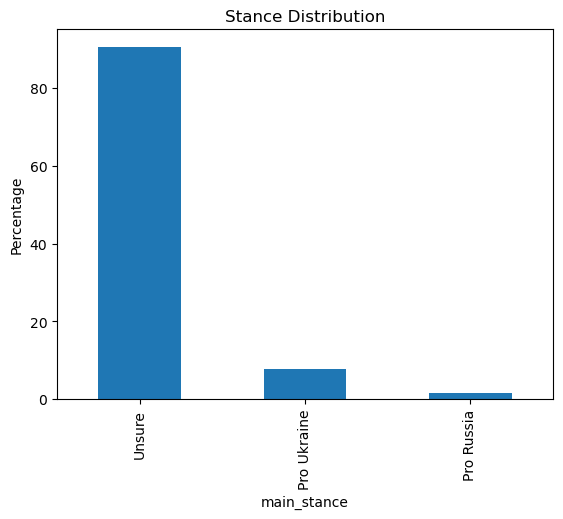

In [ ]:
import matplotlib.pyplot as plt

df["main_stance"].value_counts(normalize=True).mul(100).plot(
    kind="bar"
)

plt.ylabel("Percentage")
plt.title("Stance Distribution")
plt.show()

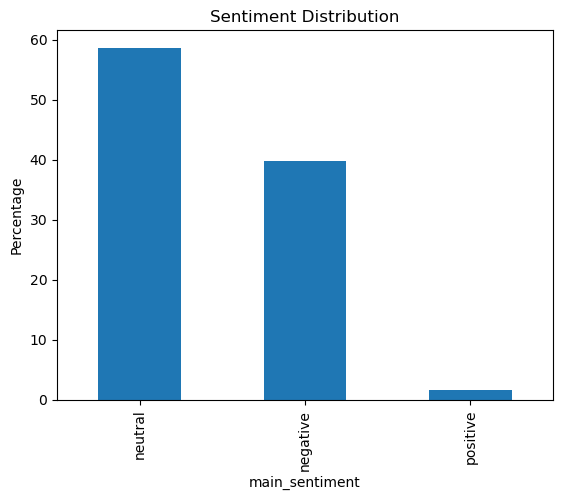

In [ ]:
df["main_sentiment"].value_counts(normalize=True).mul(100).plot(
    kind="bar"
)

plt.ylabel("Percentage")
plt.title("Sentiment Distribution")
plt.show()

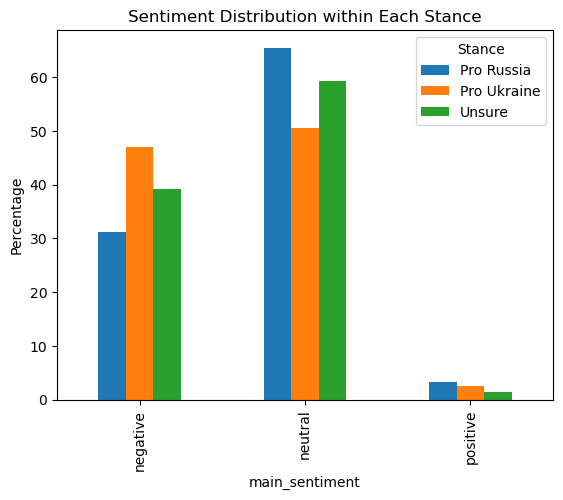

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cross = pd.crosstab(
    df["main_sentiment"],
    df["main_stance"],
    normalize="columns"
) * 100

cross.plot(kind="bar")

plt.ylabel("Percentage")
plt.title("Sentiment Distribution within Each Stance")
plt.legend(title="Stance")
plt.show()

In [ ]:
pip install contractions

In [ ]:
import contractions

def expand_contractions(text):
    if isinstance(text, str):
        return contractions.fix(text)
    return text

df["reconstructed_text"] = df["reconstructed_text"].apply(expand_contractions)

In [ ]:
print(df["lang"].nunique())
print(df["country"].nunique())

60
124


In [ ]:
pip install nltk

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

keep_words = {
    "not",
    "no",
    "nor",
    "never",
    "against"
}

custom_stopwords = stop_words - keep_words

In [ ]:
df['reconstructed_text'].iloc[923456]

'ukraine mocks putin and advises russian soldiers not to smoke on their bases toavoid misfortune'

In [ ]:
def remove_stopwords(text):
    words = text.split()
    return " ".join(
        word for word in words
        if word.lower() not in custom_stopwords
    )

df["reconstructed_text"] = df["reconstructed_text"].apply(remove_stopwords)

In [ ]:
df['reconstructed_text'].iloc[923456]

'ukraine mocks putin advises russian soldiers not smoke bases toavoid misfortune'

In [ ]:
df.to_csv("cleaned_russia_ukraine_dataset.csv", index=False)

In [ ]:
df.isnull().sum()

lang                  0
country               0
reconstructed_text    0
main_sentiment        0
sentiment_score       0
main_stance           0
stance_score          0
dtype: int64

In [ ]:
(df["reconstructed_text"] == "").sum()

np.int64(12)